In [51]:
# Cell 1: Import Libraries and Check GPU
import os
import gc
import time
import random

import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from transformers import (
    AutoTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)

from peft import (
    LoraConfig,
    TaskType,
    get_peft_model
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.14.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 2070 Super


In [58]:
# Cell 2: Formal experiment configuration

MODEL_NAME = "bert-base-uncased"
NUM_LABELS = 4
MAX_LENGTH = 128

# Batch size
BATCH_SIZE = 8

# Learning rates
# Tutor suggested a higher learning rate for LoRA
LORA_LEARNING_RATE = 2e-4

# Full fine-tuning uses a lower learning rate
FULL_FT_LEARNING_RATE = 2e-5

# LoRA hyperparameters
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.1


# Use a smaller subset for placement search
SEARCH_TRAIN_SIZE = 10000

# All 8 placement candidates use the same number of epochs
SEARCH_MAX_EPOCHS = 8

# One seed for placement search
SEARCH_SEED = 231

# Five seeds will be used for final comparison
FINAL_SEEDS = [231, 42, 123, 456, 789]

# Main selection metric
SELECTION_METRIC = "macro_f1"

RESULTS_DIR = "formal_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Model:", MODEL_NAME)
print("LoRA learning rate:", LORA_LEARNING_RATE)
print("Full FT learning rate:", FULL_FT_LEARNING_RATE)
print("Search training size:", SEARCH_TRAIN_SIZE)
print("Search epochs:", SEARCH_MAX_EPOCHS)
print("Search seed:", SEARCH_SEED)
print("Final seeds:", FINAL_SEEDS)

Model: bert-base-uncased
LoRA learning rate: 0.0002
Full FT learning rate: 2e-05
Search training size: 10000
Search epochs: 8
Search seed: 231
Final seeds: [231, 42, 123, 456, 789]


In [13]:
# Cell 3: LoRA placement search space

MODULE_GROUPS = {
    "QV": ["query", "value"],
    "QKV": ["query", "key", "value"]
}

LAYER_GROUPS = {
    "lower": [0, 1, 2, 3],
    "middle": [4, 5, 6, 7],
    "upper": [8, 9, 10, 11],
    "all": list(range(12))
}

candidates = []

for module_name, target_modules in MODULE_GROUPS.items():
    for layer_name, layer_indices in LAYER_GROUPS.items():
        candidates.append({
            "candidate": f"{module_name}_{layer_name}",
            "module_group": module_name,
            "target_modules": target_modules,
            "layer_group": layer_name,
            "layer_indices": layer_indices
        })

candidate_df = pd.DataFrame(candidates)

candidate_df[
    ["candidate", "module_group", "layer_group", "layer_indices"]
]

,candidate,module_group,layer_group,layer_indices
0,QV_lower,QV,lower,"[0, 1, 2, 3]"
1,QV_middle,QV,middle,"[4, 5, 6, 7]"
2,QV_upper,QV,upper,"[8, 9, 10, 11]"
3,QV_all,QV,all,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
4,QKV_lower,QKV,lower,"[0, 1, 2, 3]"
5,QKV_middle,QKV,middle,"[4, 5, 6, 7]"
6,QKV_upper,QKV,upper,"[8, 9, 10, 11]"
7,QKV_all,QKV,all,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"


In [14]:
# Cell 4: Load and split AG News dataset

dataset = load_dataset("fancyzhx/ag_news")

official_train = dataset["train"]
official_test = dataset["test"]

# Stratified 90/10 split of the official training set
train_indices, val_indices = train_test_split(
    np.arange(len(official_train)),
    test_size=0.10,
    random_state=231,
    stratify=official_train["label"]
)

train_dataset = official_train.select(train_indices)
val_dataset = official_train.select(val_indices)
test_dataset = official_test

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Training samples: 108000
Validation samples: 12000
Test samples: 7600


In [15]:
# Cell 5: Check class distribution

LABEL_NAMES = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

def show_class_distribution(dataset_split, name):
    labels = np.array(dataset_split["label"])
    
    print(f"\n{name}")
    print("-" * 30)
    
    for label_id, label_name in enumerate(LABEL_NAMES):
        count = np.sum(labels == label_id)
        percentage = count / len(labels) * 100
        
        print(
            f"{label_id} - {label_name}: "
            f"{count} ({percentage:.2f}%)"
        )

show_class_distribution(train_dataset, "Training Set")
show_class_distribution(val_dataset, "Validation Set")
show_class_distribution(test_dataset, "Test Set")


Training Set
------------------------------
0 - World: 27000 (25.00%)
1 - Sports: 27000 (25.00%)
2 - Business: 27000 (25.00%)
3 - Sci/Tech: 27000 (25.00%)

Validation Set
------------------------------
0 - World: 3000 (25.00%)
1 - Sports: 3000 (25.00%)
2 - Business: 3000 (25.00%)
3 - Sci/Tech: 3000 (25.00%)

Test Set
------------------------------
0 - World: 1900 (25.00%)
1 - Sports: 1900 (25.00%)
2 - Business: 1900 (25.00%)
3 - Sci/Tech: 1900 (25.00%)


In [16]:
# Cell 6: Load BERT tokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer:", MODEL_NAME)
print("Vocabulary size:", tokenizer.vocab_size)
print("Maximum length used:", MAX_LENGTH)

Tokenizer: bert-base-uncased
Vocabulary size: 30522
Maximum length used: 128


In [54]:
# Cell 7: Tokenize datasets
# Convert news text into BERT inputs with a maximum length of 128 tokens.
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )
# Tokenize training, validation, and test sets separately.
# Remove raw text but keep labels for training and evaluation.
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

print("Tokenized training samples:", len(tokenized_train))
print("Tokenized validation samples:", len(tokenized_val))
print("Tokenized test samples:", len(tokenized_test))

Tokenized training samples: 108000
Tokenized validation samples: 12000
Tokenized test samples: 7600


In [55]:
# Cell 8: Inspect one tokenized example
# Check the original text, label, and tokenized output.
example_id = 0

print("Original text:")
print(train_dataset[example_id]["text"])

print("\nLabel:")
print(
    train_dataset[example_id]["label"],
    "-",
    LABEL_NAMES[train_dataset[example_id]["label"]]
)

print("\nFirst 20 token IDs:")
print(tokenized_train[example_id]["input_ids"][:20])

print("\nDecoded tokens:")
print(
    tokenizer.convert_ids_to_tokens(
        tokenized_train[example_id]["input_ids"][:20]
    )
)

Original text:
Pulitzer Inc. for sale? ST. LOUIS The newspaper publisher Pulitzer Inc. has said that company officials are considering a possible sale of the firm to improve shareholder value.

Label:
2 - Business

First 20 token IDs:
[101, 17618, 4297, 1012, 2005, 5096, 1029, 2358, 1012, 3434, 1996, 3780, 6674, 17618, 4297, 1012, 2038, 2056, 2008, 2194]

Decoded tokens:
['[CLS]', 'pulitzer', 'inc', '.', 'for', 'sale', '?', 'st', '.', 'louis', 'the', 'newspaper', 'publisher', 'pulitzer', 'inc', '.', 'has', 'said', 'that', 'company']


In [56]:
# Cell 9: Evaluation metrics
# Evaluate classification performance using Accuracy and Macro-F1.
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

In [20]:
# Create a balanced 10,000-sample subset for placement search

from datasets import concatenate_datasets

samples_per_class = SEARCH_TRAIN_SIZE // NUM_LABELS

search_parts = []

for label in range(NUM_LABELS):

    class_dataset = tokenized_train.filter(
        lambda example: example["label"] == label
    )

    class_dataset = class_dataset.shuffle(seed=SEARCH_SEED)

    class_subset = class_dataset.select(
        range(samples_per_class)
    )

    search_parts.append(class_subset)

search_train_dataset = concatenate_datasets(search_parts)

# Shuffle the combined subset
search_train_dataset = search_train_dataset.shuffle(
    seed=SEARCH_SEED
)

print("SEARCH_TRAIN_SIZE:", SEARCH_TRAIN_SIZE)
print("Actual search dataset size:", len(search_train_dataset))

# Check class distribution
labels = search_train_dataset["label"]

for label in range(NUM_LABELS):
    print(
        f"Class {label}:",
        labels.count(label)
    )

Filter:   0%|          | 0/108000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/108000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/108000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/108000 [00:00<?, ? examples/s]

SEARCH_TRAIN_SIZE: 10000
Actual search dataset size: 10000
Class 0: 2500
Class 1: 2500
Class 2: 2500
Class 3: 2500


In [57]:
# Cell 10: Build a LoRA model for a specific placement

def build_lora_model(target_modules, layer_indices):

    # Fresh pretrained BERT for every candidate
    model = BertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS
    )
# Apply LoRA only to the selected attention modules and encoder layers.
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=target_modules,
        layers_to_transform=layer_indices,
        layers_pattern="layer",
        bias="none"
    )

    model = get_peft_model(model, lora_config)

    return model

In [22]:
# Cell 11: Verify one placement before training

test_model = build_lora_model(
    target_modules=MODULE_GROUPS["QV"],
    layer_indices=LAYER_GROUPS["lower"]
)

test_model.print_trainable_parameters()

# Show trainable LoRA parameters

for name, param in test_model.named_parameters():
    if param.requires_grad and "lora_" in name:
        print(name)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 101,380 || all params: 109,586,696 || trainable%: 0.0925
base_model.model.bert.encoder.layer.0.attention.self.query.lora_A.default.weight
base_model.model.bert.encoder.layer.0.attention.self.query.lora_B.default.weight
base_model.model.bert.encoder.layer.0.attention.self.value.lora_A.default.weight
base_model.model.bert.encoder.layer.0.attention.self.value.lora_B.default.weight
base_model.model.bert.encoder.layer.1.attention.self.query.lora_A.default.weight
base_model.model.bert.encoder.layer.1.attention.self.query.lora_B.default.weight
base_model.model.bert.encoder.layer.1.attention.self.value.lora_A.default.weight
base_model.model.bert.encoder.layer.1.attention.self.value.lora_B.default.weight
base_model.model.bert.encoder.layer.2.attention.self.query.lora_A.default.weight
base_model.model.bert.encoder.layer.2.attention.self.query.lora_B.default.weight
base_model.model.bert.encoder.layer.2.attention.self.value.lora_A.default.weight
base_model.model.bert.encoder.laye

In [23]:
# Cell 12: Train and evaluate one LoRA placement candidate

def train_candidate(candidate, seed=SEARCH_SEED):

    candidate_name = candidate["candidate"]
    target_modules = candidate["target_modules"]
    layer_indices = candidate["layer_indices"]

    print("=" * 70)
    print(f"Training candidate: {candidate_name}")
    print(f"Target modules: {target_modules}")
    print(f"Layers: {layer_indices}")
    print(f"Seed: {seed}")
    print(f"Training samples: {len(search_train_dataset)}")
    print(f"Maximum epochs: {SEARCH_MAX_EPOCHS}")
    print("=" * 70)

    # Reproducibility
    set_seed(seed)

    # Clear GPU memory
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    # Load a fresh BERT model and apply LoRA
    model = build_lora_model(
        target_modules=target_modules,
        layer_indices=layer_indices
    )

    # Count parameters
    trainable_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable_percent = (
        100 * trainable_params / total_params
    )

    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Trainable percentage: {trainable_percent:.4f}%")

    # Output directory
    output_dir = os.path.join(
        RESULTS_DIR,
        f"{candidate_name}_seed{seed}"
    )

    # Training settings
    training_args = TrainingArguments(
        output_dir=output_dir,

        num_train_epochs=SEARCH_MAX_EPOCHS,

        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,

        learning_rate=LORA_LEARNING_RATE,

        eval_strategy="epoch",
        save_strategy="epoch",

        # Keep the checkpoint with the best validation Macro-F1
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,

        save_total_limit=1,

        # Record training/evaluation information every epoch
        logging_strategy="epoch",

        seed=seed,
        data_seed=seed,

        report_to="none"
    )

    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,

        # Smaller subset is used only for placement search
        train_dataset=search_train_dataset,

        # Full validation set is used for candidate selection
        eval_dataset=tokenized_val,

        compute_metrics=compute_metrics
    )

    # Measure training time
    start_time = time.time()

    trainer.train()

    training_time = time.time() - start_time


    # Save validation performance for every epoch


    epoch_history = []

    for log in trainer.state.log_history:

        if "eval_macro_f1" in log:

            epoch_history.append({
                "candidate": candidate_name,
                "seed": seed,
                "epoch": log.get("epoch"),
                "validation_loss": log.get("eval_loss"),
                "accuracy": log.get("eval_accuracy"),
                "macro_f1": log.get("eval_macro_f1")
            })

    # Save epoch history immediately
    history_df = pd.DataFrame(epoch_history)

    history_path = os.path.join(
        RESULTS_DIR,
        f"{candidate_name}_seed{seed}_history.csv"
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    # Evaluate best checkpoint

    validation_results = trainer.evaluate(
        tokenized_val
    )

    # Best epoch/checkpoint selected by validation Macro-F1
    best_checkpoint = trainer.state.best_model_checkpoint
    best_metric = trainer.state.best_metric

    # Peak GPU memory
    if torch.cuda.is_available():
        peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / 1024**3
        )
    else:
        peak_memory_gb = None

    # Store summary result
    result = {
        "candidate": candidate_name,
        "seed": seed,
        "training_samples": len(search_train_dataset),
        "max_epochs": SEARCH_MAX_EPOCHS,

        "macro_f1": validation_results["eval_macro_f1"],
        "accuracy": validation_results["eval_accuracy"],
        "validation_loss": validation_results["eval_loss"],

        "best_macro_f1": best_metric,
        "best_checkpoint": best_checkpoint,

        "trainable_params": trainable_params,
        "trainable_percent": trainable_percent,

        "training_time_seconds": training_time,
        "peak_gpu_memory_gb": peak_memory_gb
    }

    # Clean up GPU memory
    del trainer
    del model

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

In [27]:
# Cell 13: Test one placement candidate

test_result = train_candidate(
    candidates[0],
    seed=SEARCH_SEED
)

print("\nTest result:")

for key, value in test_result.items():
    print(f"{key}: {value}")

Training candidate: QV_lower
Target modules: ['query', 'value']
Layers: [0, 1, 2, 3]
Seed: 231
Training samples: 30000
Epochs: 5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 101,380
Trainable percentage: 0.0925%


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.463197,0.343888,0.904167,0.904403
2,0.326817,0.326938,0.909583,0.909635
3,0.291323,0.339874,0.913583,0.913407
4,0.269611,0.325533,0.912833,0.912689
5,0.253382,0.316611,0.916250,0.916120


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.253382,0.316611,5,0.916250,0.916120



Test result:
candidate: QV_lower
seed: 231
training_samples: 30000
epochs: 5
macro_f1: 0.9161200605131244
accuracy: 0.91625
validation_loss: 0.31661131978034973
trainable_params: 101380
trainable_percent: 0.09251122964780323
training_time_seconds: 7786.914693117142
peak_gpu_memory_gb: 1.2675909996032715


In [42]:
# Cell 14: Run formal placement search

import os
import gc
import pandas as pd
import torch

search_results = []

for i, candidate in enumerate(candidates):

    candidate_name = candidate["candidate"]

    print("\n" + "=" * 70)
    print(f"Placement Search {i+1}/{len(candidates)}: {candidate_name}")
    print("=" * 70)

    result = train_candidate(
        candidate,
        seed=SEARCH_SEED
    )

    search_results.append(result)

    # Save immediately after each candidate
    search_df = pd.DataFrame(search_results)

    search_df.to_csv(
        os.path.join(RESULTS_DIR, "placement_search_results.csv"),
        index=False
    )

    print(f"\nSaved result for {candidate_name}")
    print(f"Completed: {i+1}/{len(candidates)}")

    # Free GPU memory before next candidate
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nPlacement search completed.")


Placement Search 1/8: QV_lower
Training candidate: QV_lower
Target modules: ['query', 'value']
Layers: [0, 1, 2, 3]
Seed: 231
Training samples: 10000
Maximum epochs: 8


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 101,380
Trainable percentage: 0.0925%


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.619585,0.416684,0.877583,0.876647
2,0.375712,0.368443,0.892583,0.892569
3,0.345812,0.347499,0.902500,0.902449
4,0.314458,0.365593,0.902167,0.902117
5,0.295624,0.355973,0.906417,0.906313
6,0.276361,0.358889,0.904083,0.903983
7,0.266970,0.356875,0.906500,0.906490
8,0.250802,0.359448,0.907167,0.907055


...

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 445,444
Trainable percentage: 0.4052%


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.446224,0.308752,0.909750,0.909452
2,0.275319,0.285721,0.915500,0.915491
3,0.228885,0.316922,0.915750,0.915833
4,0.198824,0.295360,0.923750,0.923827
5,0.168656,0.311323,0.921833,0.921944
6,0.144800,0.319011,0.924917,0.924945
7,0.127955,0.332036,0.923833,0.923818
8,0.117042,0.342067,0.923583,0.923603


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.117042,0.319011,8,0.924917,0.924945



Saved result for QKV_all
Completed: 8/8

Placement search completed.


In [25]:
# Cell 15: Load and rank saved LoRA placement results

import os
import pandas as pd

# Load previously saved placement search results
search_file = os.path.join(
    RESULTS_DIR,
    "placement_search_results.csv"
)

search_df = pd.read_csv(search_file)

# Rank by validation Macro-F1
ranking_df = search_df.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

ranking_df.insert(
    0,
    "rank",
    range(1, len(ranking_df) + 1)
)

display(
    ranking_df[
        [
            "rank",
            "candidate",
            "macro_f1",
            "accuracy",
            "validation_loss",
            "trainable_params",
            "trainable_percent",
            "training_time_seconds",
            "peak_gpu_memory_gb"
        ]
    ]
)

# Best candidate
BEST_CANDIDATE_NAME = ranking_df.iloc[0]["candidate"]

best_candidate = next(
    c for c in candidates
    if c["candidate"] == BEST_CANDIDATE_NAME
)

print("\nBest LoRA placement:", BEST_CANDIDATE_NAME)
print("Target modules:", best_candidate["target_modules"])
print("Layers:", best_candidate["layer_indices"])
print("Validation Macro-F1:", ranking_df.iloc[0]["macro_f1"])
print("Trainable parameters:", ranking_df.iloc[0]["trainable_params"])

,rank,candidate,macro_f1,accuracy,validation_loss,trainable_params,trainable_percent,training_time_seconds,peak_gpu_memory_gb
0,1,QKV_all,0.924945,0.924917,0.319011,445444,0.405204,4612.839384,1.512044
1,2,QV_all,0.921909,0.921833,0.325355,297988,0.271433,4213.057369,1.466805
2,3,QV_upper,0.918210,0.918333,0.299211,101380,0.092511,2971.489932,1.155023
3,4,QKV_upper,0.918083,0.918083,0.320641,150532,0.137302,3047.773926,1.169614
4,5,QKV_middle,0.914921,0.914917,0.322777,150532,0.137302,3368.311093,1.294858
5,6,QV_middle,0.913845,0.913750,0.317737,101380,0.092511,3390.717371,1.280267
6,7,QKV_lower,0.910688,0.910750,0.360682,150532,0.137302,4088.983771,1.420102
7,8,QV_lower,0.907055,0.907167,0.359448,101380,0.092511,4353.555781,1.405511



Best LoRA placement: QKV_all
Target modules: ['query', 'key', 'value']
Layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Validation Macro-F1: 0.924944875779342
Trainable parameters: 445444


In [26]:
# Cell 16: Final comparison configuration

# Use a larger subset for the final comparison
FINAL_TRAIN_SIZE = 12000

# Maximum number of epochs
FINAL_MAX_EPOCHS = 8

# Multiple seeds for robust final results
FINAL_SEEDS = [231, 42, 123, 456, 789]

# Final methods
FINAL_METHODS = [
    "Frozen_BERT",
    "Full_FT",
    "Standard_LoRA",
    "Selected_LoRA"
]

print("Final training samples:", FINAL_TRAIN_SIZE)
print("Final maximum epochs:", FINAL_MAX_EPOCHS)
print("Final seeds:", FINAL_SEEDS)
print("Final methods:", FINAL_METHODS)

print("\nStandard LoRA:")
print("  Modules: Q + V")
print("  Layers: all 12")

print("\nSelected LoRA:")
print("  Modules:", best_candidate["target_modules"])
print("  Layers:", best_candidate["layer_indices"])

Final training samples: 12000
Final maximum epochs: 8
Final seeds: [231, 42, 123, 456, 789]
Final methods: ['Frozen_BERT', 'Full_FT', 'Standard_LoRA', 'Selected_LoRA']

Standard LoRA:
  Modules: Q + V
  Layers: all 12

Selected LoRA:
  Modules: ['query', 'key', 'value']
  Layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


In [27]:
# Cell 17: Create final training subset

# Use the same subset for all final methods and all seeds
rng = np.random.default_rng(231)

final_indices = rng.choice(
    len(tokenized_train),
    size=FINAL_TRAIN_SIZE,
    replace=False
)

final_train_dataset = tokenized_train.select(
    final_indices.tolist()
)

print("Original training samples:", len(tokenized_train))
print("Final training samples:", len(final_train_dataset))
print("Validation samples:", len(tokenized_val))
print("Test samples:", len(tokenized_test))

Original training samples: 108000
Final training samples: 12000
Validation samples: 12000
Test samples: 7600


In [28]:
# Cell 18: Build models for final comparison

def build_final_model(method_name):

    # Fresh BERT model for every run
    model = BertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS
    )


    # 1. Frozen BERT
    
    if method_name == "Frozen_BERT":

        # Freeze the entire BERT encoder
        for param in model.bert.parameters():
            param.requires_grad = False

        # Classification head remains trainable


    # 2. Full Fine-Tuning

    elif method_name == "Full_FT":

        # All parameters remain trainable
        pass

 
    # 3. Standard LoRA: Q + V on all 12 layers

    elif method_name == "Standard_LoRA":

        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=LORA_R,
            lora_alpha=LORA_ALPHA,
            lora_dropout=LORA_DROPOUT,
            target_modules=["query", "value"],
            layers_to_transform=list(range(12)),
            layers_pattern="layer",
            bias="none"
        )

        model = get_peft_model(model, lora_config)


    # 4. Selected LoRA: best placement from search

    elif method_name == "Selected_LoRA":

        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=LORA_R,
            lora_alpha=LORA_ALPHA,
            lora_dropout=LORA_DROPOUT,
            target_modules=best_candidate["target_modules"],
            layers_to_transform=best_candidate["layer_indices"],
            layers_pattern="layer",
            bias="none"
        )

        model = get_peft_model(model, lora_config)

    else:
        raise ValueError(
            f"Unknown method: {method_name}"
        )

    return model

In [29]:
# Cell 19: Verify trainable parameters for final methods

parameter_summary = []

for method_name in FINAL_METHODS:

    print("\n" + "=" * 60)
    print("Method:", method_name)

    model = build_final_model(method_name)

    trainable_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable_percent = (
        100 * trainable_params / total_params
    )

    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable percentage: {trainable_percent:.4f}%")

    parameter_summary.append({
        "method": method_name,
        "trainable_params": trainable_params,
        "total_params": total_params,
        "trainable_percent": trainable_percent
    })

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

parameter_df = pd.DataFrame(parameter_summary)

display(parameter_df)


Method: Frozen_BERT


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable parameters: 3,076
Total parameters: 109,485,316
Trainable percentage: 0.0028%

Method: Full_FT


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable parameters: 109,485,316
Total parameters: 109,485,316
Trainable percentage: 100.0000%

Method: Standard_LoRA


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable parameters: 297,988
Total parameters: 109,783,304
Trainable percentage: 0.2714%

Method: Selected_LoRA


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable parameters: 445,444
Total parameters: 109,930,760
Trainable percentage: 0.4052%


,method,trainable_params,total_params,trainable_percent
0,Frozen_BERT,3076,109485316,0.002810
1,Full_FT,109485316,109485316,100.000000
2,Standard_LoRA,297988,109783304,0.271433
3,Selected_LoRA,445444,109930760,0.405204


In [59]:
# Cell 20: Train one final comparison run

def train_final_method(method_name, seed):

    print("=" * 70)
    print(f"Method: {method_name}")
    print(f"Seed: {seed}")
    print(f"Training samples: {len(final_train_dataset)}")
    print(f"Maximum epochs: {FINAL_MAX_EPOCHS}")
    print("=" * 70)

    # Reproducibility
    set_seed(seed)

    # Clear GPU memory
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    # Build a fresh model
    model = build_final_model(method_name)

    # Count parameters
    trainable_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable_percent = (
        100 * trainable_params / total_params
    )

    # Different learning rates
    if method_name == "Full_FT":
        learning_rate = FULL_FT_LEARNING_RATE
    else:
        learning_rate = LORA_LEARNING_RATE

    # Frozen BERT trains only the classification head using the LoRA learning rate.

    print(f"Learning rate: {learning_rate}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Trainable percentage: {trainable_percent:.4f}%")

    output_dir = os.path.join(
        RESULTS_DIR,
        "final_comparison",
        f"{method_name}_seed{seed}"
    )

    training_args = TrainingArguments(
        output_dir=output_dir,

        num_train_epochs=FINAL_MAX_EPOCHS,

        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,

        learning_rate=learning_rate,

        eval_strategy="epoch",
        save_strategy="epoch",

        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,

        save_total_limit=1,

        logging_strategy="epoch",

        seed=seed,
        data_seed=seed,

        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=final_train_dataset,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics
    )

    # Training time
    start_time = time.time()

    trainer.train()

    training_time = time.time() - start_time

    # Validation performance
    validation_results = trainer.evaluate(
        tokenized_val
    )

    # Test performance
    test_results = trainer.evaluate(
        tokenized_test,
        metric_key_prefix="test"
    )

    # GPU memory
    if torch.cuda.is_available():
        peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / 1024**3
        )
    else:
        peak_memory_gb = None

    result = {
        "method": method_name,
        "seed": seed,

        "training_samples": len(final_train_dataset),
        "max_epochs": FINAL_MAX_EPOCHS,
        "learning_rate": learning_rate,

        "val_macro_f1": validation_results["eval_macro_f1"],
        "val_accuracy": validation_results["eval_accuracy"],

        "test_macro_f1": test_results["test_macro_f1"],
        "test_accuracy": test_results["test_accuracy"],

        "trainable_params": trainable_params,
        "trainable_percent": trainable_percent,

        "training_time_seconds": training_time,
        "peak_gpu_memory_gb": peak_memory_gb
    }

    # Save epoch history for later plots
    history_df = pd.DataFrame(trainer.state.log_history)

    history_file = os.path.join(
        RESULTS_DIR,
        "final_comparison",
        f"{method_name}_seed{seed}_history.csv"
    )

    os.makedirs(
        os.path.dirname(history_file),
        exist_ok=True
    )

    history_df.to_csv(
        history_file,
        index=False
    )

    # Cleanup
    del trainer
    del model

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result

In [35]:
# Cell 21: Run all final comparison experiments

import os
import pandas as pd
import gc
import torch

final_results_file = os.path.join(
    RESULTS_DIR,
    "final_comparison",
    "final_results.csv"
)

os.makedirs(
    os.path.dirname(final_results_file),
    exist_ok=True
)

# Load previously completed runs if they exist

if os.path.exists(final_results_file):
    final_results_df = pd.read_csv(final_results_file)
    final_results = final_results_df.to_dict("records")

    print(
        f"Loaded {len(final_results)} completed run(s)."
    )
else:
    final_results = []

    print("Loaded 0 completed run(s).")


# Check whether a run has already been completed

def run_completed(method_name, seed):

    for result in final_results:

        if (
            result["method"] == method_name
            and int(result["seed"]) == int(seed)
        ):
            return True

    return False


# Total number of final experiments

total_runs = len(FINAL_METHODS) * len(FINAL_SEEDS)

completed_runs = len(final_results)



# Run experiments

for method_name in FINAL_METHODS:

    for seed in FINAL_SEEDS:

        # Skip already completed experiments
        if run_completed(method_name, seed):

            print(
                f"Skipping completed run: "
                f"{method_name}, seed={seed}"
            )

            continue


        print("\n" + "=" * 70)

        print(
            f"Final experiment: {method_name}"
        )

        print(
            f"Seed: {seed}"
        )

        print(
            f"Completed runs: "
            f"{completed_runs}/{total_runs}"
        )

        print("=" * 70)


        # Run one experiment
        result = train_final_method(
            method_name,
            seed
        )


        # Store result
        final_results.append(result)

        completed_runs += 1


        # Save immediately after every run
        final_results_df = pd.DataFrame(
            final_results
        )

        final_results_df.to_csv(
            final_results_file,
            index=False
        )


        print("\nRun saved successfully.")

        print(
            f"{method_name} | "
            f"seed={seed} | "
            f"Test Macro-F1="
            f"{result['test_macro_f1']:.6f}"
        )

        print(
            f"Completed: "
            f"{completed_runs}/{total_runs}"
        )


        # GPU cleanup between runs
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()



# Summary

print("\n" + "=" * 70)
print("All final experiments completed.")
print("=" * 70)

final_results_df = pd.DataFrame(
    final_results
)

display(final_results_df)

Loaded 0 completed run(s).

Final experiment: Frozen_BERT
Seed: 231
Completed runs: 0/20
Method: Frozen_BERT
Seed: 231
Training samples: 12000
Maximum epochs: 8


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Learning rate: 0.0002
Trainable parameters: 3,076
Trainable percentage: 0.0028%


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.158100,0.980249,0.674917,0.668259
2,0.936800,0.837824,0.739750,0.735374
3,0.836800,0.765356,0.763333,0.763637
4,0.776500,0.730175,0.764583,0.762365
5,0.741400,0.688275,0.787750,0.787477
6,0.720700,0.674799,0.790250,0.788607
7,0.705100,0.665900,0.793333,0.792002
8,0.698700,0.660685,0.794667,0.793140



Run saved successfully.
Frozen_BERT | seed=231 | Test Macro-F1=0.782898
Completed: 1/20

Final experiment: Frozen_BERT
Seed: 42
Completed runs: 1/20
Method: Frozen_BERT
Seed: 42
Training samples: 12000
Maximum epochs: 8


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Learning rate: 0.0002
Trainable parameters: 445,444
Trainable percentage: 0.4052%


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.430600,0.300474,0.910333,0.909996
2,0.273000,0.312722,0.916667,0.916477
3,0.224300,0.285939,0.921333,0.921083
4,0.193800,0.315280,0.921917,0.921684
5,0.164300,0.303305,0.926167,0.926195
6,0.144000,0.322012,0.925500,0.925528
7,0.117500,0.347723,0.923583,0.923454
8,0.107100,0.350647,0.924417,0.924330



Run saved successfully.
Selected_LoRA | seed=789 | Test Macro-F1=0.923336
Completed: 20/20

All final experiments completed.


,method,seed,training_samples,max_epochs,learning_rate,val_macro_f1,val_accuracy,test_macro_f1,test_accuracy,trainable_params,trainable_percent,training_time_seconds,peak_gpu_memory_gb
0,Frozen_BERT,231,12000,8,0.00020,0.793140,0.794667,0.782898,0.784342,3076,0.002810,3054.703412,0.459364
1,Frozen_BERT,42,12000,8,0.00020,0.793199,0.795000,0.782194,0.783816,3076,0.002810,3117.133488,0.459608
2,Frozen_BERT,123,12000,8,0.00020,0.793404,0.795083,0.783589,0.785132,3076,0.002810,3089.222298,0.459608
3,Frozen_BERT,456,12000,8,0.00020,0.793805,0.795333,0.781798,0.783289,3076,0.002810,3057.657226,0.459608
4,Frozen_BERT,789,12000,8,0.00020,0.792157,0.793583,0.783404,0.784737,3076,0.002810,3068.887481,0.459608
5,Full_FT,231,12000,8,0.00002,0.926986,0.927083,0.926163,0.926316,109485316,100.000000,7031.470452,1.863155
6,Full_FT,42,12000,8,0.00002,0.927338,0.927417,0.922353,0.922500,109485316,100.000000,6778.920769,1.863155
7,Full_FT,123,12000,8,0.00002,0.927345,0.927417,0.923143,0.923158,109485316,100.000000,6917.413757,1.863155
8,Full_FT,456,12000,8,0.00002,0.927907,0.927917,0.922792,0.922895,109485316,100.000000,7520.055559,1.863155
9,Full_FT,789,12000,8,0.00002,0.926271,0.926333,0.920944,0.921053,109485316,100.000000,6986.392306,1.863155


In [36]:
# Cell 22: Verify final experiment results

import os
import pandas as pd

final_results_file = os.path.join(
    RESULTS_DIR,
    "final_comparison",
    "final_results.csv"
)

print("Results file:")
print(final_results_file)

print("\nFile exists:")
print(os.path.exists(final_results_file))

if os.path.exists(final_results_file):

    final_df = pd.read_csv(final_results_file)

    print("\nNumber of saved runs:")
    print(len(final_df))

    print("\nRuns per method:")
    print(final_df.groupby("method").size())

    print("\nSeeds per method:")
    print(
        final_df.groupby("method")["seed"]
        .apply(list)
    )

    print("\nDuplicate method-seed runs:")
    duplicates = final_df.duplicated(
        subset=["method", "seed"]
    ).sum()

    print(duplicates)

    print("\nMissing values:")
    print(final_df.isnull().sum())

    print("\nFinal saved results:")
    display(final_df)

Results file:
formal_results\final_comparison\final_results.csv

File exists:
True

Number of saved runs:
20

Runs per method:
method
Frozen_BERT      5
Full_FT          5
Selected_LoRA    5
Standard_LoRA    5
dtype: int64

Seeds per method:
method
Frozen_BERT      [231, 42, 123, 456, 789]
Full_FT          [231, 42, 123, 456, 789]
Selected_LoRA    [231, 42, 123, 456, 789]
Standard_LoRA    [231, 42, 123, 456, 789]
Name: seed, dtype: object

Duplicate method-seed runs:
0

Missing values:
method                   0
seed                     0
training_samples         0
max_epochs               0
learning_rate            0
val_macro_f1             0
val_accuracy             0
test_macro_f1            0
test_accuracy            0
trainable_params         0
trainable_percent        0
training_time_seconds    0
peak_gpu_memory_gb       0
dtype: int64

Final saved results:


,method,seed,training_samples,max_epochs,learning_rate,val_macro_f1,val_accuracy,test_macro_f1,test_accuracy,trainable_params,trainable_percent,training_time_seconds,peak_gpu_memory_gb
0,Frozen_BERT,231,12000,8,0.00020,0.793140,0.794667,0.782898,0.784342,3076,0.002810,3054.703412,0.459364
1,Frozen_BERT,42,12000,8,0.00020,0.793199,0.795000,0.782194,0.783816,3076,0.002810,3117.133488,0.459608
2,Frozen_BERT,123,12000,8,0.00020,0.793404,0.795083,0.783589,0.785132,3076,0.002810,3089.222298,0.459608
3,Frozen_BERT,456,12000,8,0.00020,0.793805,0.795333,0.781798,0.783289,3076,0.002810,3057.657226,0.459608
4,Frozen_BERT,789,12000,8,0.00020,0.792157,0.793583,0.783404,0.784737,3076,0.002810,3068.887481,0.459608
5,Full_FT,231,12000,8,0.00002,0.926986,0.927083,0.926163,0.926316,109485316,100.000000,7031.470452,1.863155
6,Full_FT,42,12000,8,0.00002,0.927338,0.927417,0.922353,0.922500,109485316,100.000000,6778.920769,1.863155
7,Full_FT,123,12000,8,0.00002,0.927345,0.927417,0.923143,0.923158,109485316,100.000000,6917.413757,1.863155
8,Full_FT,456,12000,8,0.00002,0.927907,0.927917,0.922792,0.922895,109485316,100.000000,7520.055559,1.863155
9,Full_FT,789,12000,8,0.00002,0.926271,0.926333,0.920944,0.921053,109485316,100.000000,6986.392306,1.863155


In [38]:
# Cell 23: Summarise final comparison results

import pandas as pd

# Load the verified final results
final_df = pd.read_csv(final_results_file)

# Summary across 5 random seeds
summary_df = (
    final_df
    .groupby("method")
    .agg(
        val_macro_f1_mean=("val_macro_f1", "mean"),
        val_macro_f1_std=("val_macro_f1", "std"),

        test_macro_f1_mean=("test_macro_f1", "mean"),
        test_macro_f1_std=("test_macro_f1", "std"),

        test_accuracy_mean=("test_accuracy", "mean"),
        test_accuracy_std=("test_accuracy", "std"),

        trainable_params=("trainable_params", "first"),
        trainable_percent=("trainable_percent", "first"),

        training_time_mean=("training_time_seconds", "mean"),
        training_time_std=("training_time_seconds", "std"),

        peak_gpu_memory_gb=("peak_gpu_memory_gb", "mean")
    )
    .reset_index()
)

# Convert average training time to minutes
summary_df["training_time_minutes"] = (
    summary_df["training_time_mean"] / 60
)

# Create report-friendly mean ± std columns
summary_df["Test Macro-F1"] = (
    summary_df["test_macro_f1_mean"].map(lambda x: f"{x:.4f}")
    + " ± "
    + summary_df["test_macro_f1_std"].map(lambda x: f"{x:.4f}")
)

summary_df["Test Accuracy"] = (
    summary_df["test_accuracy_mean"].map(lambda x: f"{x:.4f}")
    + " ± "
    + summary_df["test_accuracy_std"].map(lambda x: f"{x:.4f}")
)

summary_df["Validation Macro-F1"] = (
    summary_df["val_macro_f1_mean"].map(lambda x: f"{x:.4f}")
    + " ± "
    + summary_df["val_macro_f1_std"].map(lambda x: f"{x:.4f}")
)

report_summary = summary_df[
    [
        "method",
        "Validation Macro-F1",
        "Test Macro-F1",
        "Test Accuracy",
        "trainable_params",
        "trainable_percent",
        "training_time_minutes",
        "peak_gpu_memory_gb"
    ]
].copy()

report_summary["training_time_minutes"] = (
    report_summary["training_time_minutes"].round(2)
)

report_summary["peak_gpu_memory_gb"] = (
    report_summary["peak_gpu_memory_gb"].round(3)
)

report_summary["trainable_percent"] = (
    report_summary["trainable_percent"].round(4)
)

display(report_summary)

,method,Validation Macro-F1,Test Macro-F1,Test Accuracy,trainable_params,trainable_percent,training_time_minutes,peak_gpu_memory_gb
0,Frozen_BERT,0.7931 ± 0.0006,0.7828 ± 0.0008,0.7843 ± 0.0007,3076,0.0028,51.29,0.460
1,Full_FT,0.9272 ± 0.0006,0.9231 ± 0.0019,0.9232 ± 0.0019,109485316,100.0000,117.45,1.863
2,Selected_LoRA,0.9266 ± 0.0014,0.9221 ± 0.0008,0.9222 ± 0.0007,445444,0.4052,94.45,0.959
3,Standard_LoRA,0.9243 ± 0.0012,0.9218 ± 0.0024,0.9220 ± 0.0023,297988,0.2714,83.84,0.914


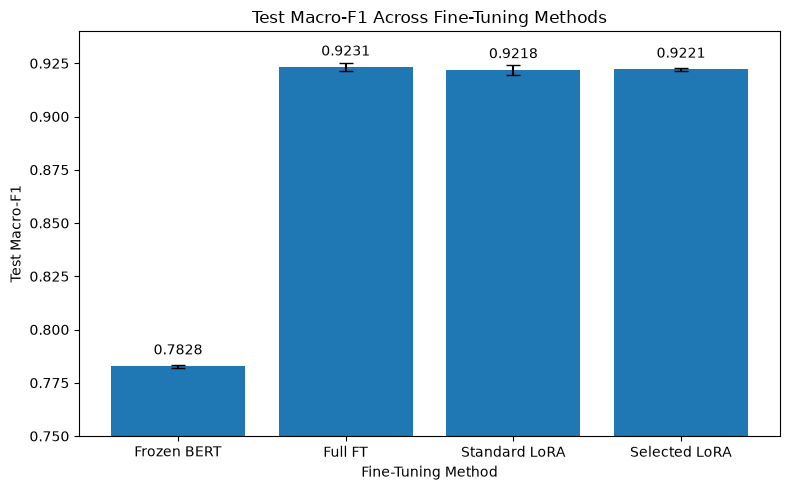

Figure saved to:
formal_results\final_comparison\test_macro_f1_comparison.png


In [41]:
# Cell 24: Plot final Test Macro-F1 comparison

import matplotlib.pyplot as plt
import numpy as np
import os

# Keep methods in a logical comparison order
method_order = [
    "Frozen_BERT",
    "Full_FT",
    "Standard_LoRA",
    "Selected_LoRA"
]

plot_df = (
    summary_df
    .set_index("method")
    .loc[method_order]
    .reset_index()
)

# More readable labels for the figure
labels = [
    "Frozen BERT",
    "Full FT",
    "Standard LoRA",
    "Selected LoRA"
]

means = plot_df["test_macro_f1_mean"].values
stds = plot_df["test_macro_f1_std"].values

x = np.arange(len(labels))

plt.figure(figsize=(8, 5))

bars = plt.bar(
    x,
    means,
    yerr=stds,
    capsize=5
)

plt.xticks(x, labels)
plt.ylabel("Test Macro-F1")
plt.xlabel("Fine-Tuning Method")
plt.title("Test Macro-F1 Across Fine-Tuning Methods")

# Focus the y-axis on the observed performance range
plt.ylim(0.75, 0.94)

# Add mean values above bars
for bar, mean in zip(bars, means):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        mean + 0.004,
        f"{mean:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

figure_path = os.path.join(
    RESULTS_DIR,
    "final_comparison",
    "test_macro_f1_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

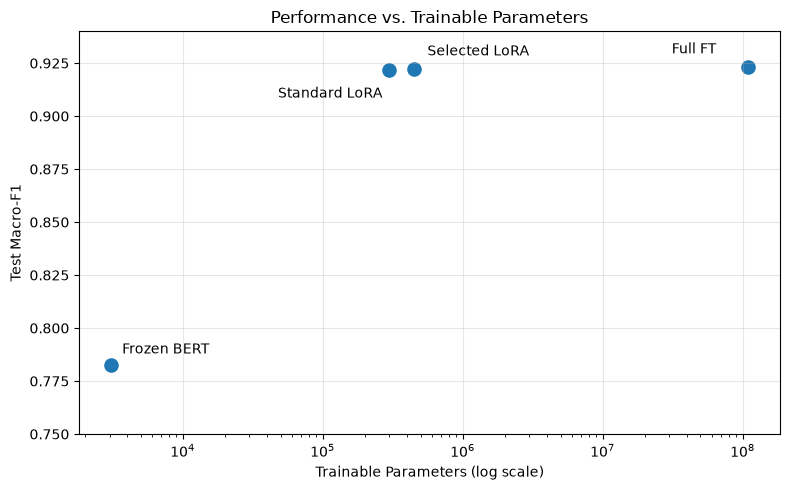

Figure saved to:
formal_results\final_comparison\performance_vs_parameters.png


In [42]:
# Cell 25: Performance vs Trainable Parameters

import matplotlib.pyplot as plt
import os

method_order = [
    "Frozen_BERT",
    "Full_FT",
    "Standard_LoRA",
    "Selected_LoRA"
]

plot_df = (
    summary_df
    .set_index("method")
    .loc[method_order]
    .reset_index()
)

labels = [
    "Frozen BERT",
    "Full FT",
    "Standard LoRA",
    "Selected LoRA"
]

x = plot_df["trainable_params"].values
y = plot_df["test_macro_f1_mean"].values

plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    y,
    s=90
)

# Log scale is necessary because Full FT has far more trainable parameters
plt.xscale("log")

# Add labels beside each point
offsets = [
    (8, 8),      # Frozen BERT
    (-55, 10),   # Full FT
    (-80, -20),  # Standard LoRA
    (10, 10)     # Selected LoRA
]

for i, label in enumerate(labels):
    plt.annotate(
        label,
        (x[i], y[i]),
        xytext=offsets[i],
        textcoords="offset points"
    )

plt.xlabel("Trainable Parameters (log scale)")
plt.ylabel("Test Macro-F1")
plt.title("Performance vs. Trainable Parameters")

plt.ylim(0.75, 0.94)
plt.grid(True, alpha=0.3)

plt.tight_layout()

figure_path = os.path.join(
    RESULTS_DIR,
    "final_comparison",
    "performance_vs_parameters.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

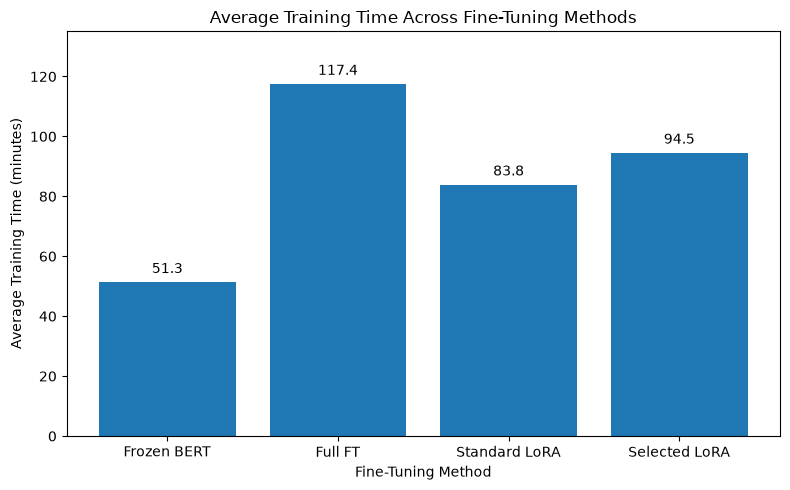

Figure saved to:
formal_results\final_comparison\training_time_comparison.png


In [43]:
# Cell 26: Average Training Time Comparison

import matplotlib.pyplot as plt
import os

method_order = [
    "Frozen_BERT",
    "Full_FT",
    "Standard_LoRA",
    "Selected_LoRA"
]

plot_df = (
    summary_df
    .set_index("method")
    .loc[method_order]
    .reset_index()
)

labels = [
    "Frozen BERT",
    "Full FT",
    "Standard LoRA",
    "Selected LoRA"
]

times = plot_df["training_time_minutes"].values

plt.figure(figsize=(8, 5))

bars = plt.bar(
    labels,
    times
)

plt.ylabel("Average Training Time (minutes)")
plt.xlabel("Fine-Tuning Method")
plt.title("Average Training Time Across Fine-Tuning Methods")

# Add values above bars
for bar, value in zip(bars, times):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}",
        ha="center",
        va="bottom"
    )

plt.ylim(0, max(times) * 1.15)
plt.tight_layout()

figure_path = os.path.join(
    RESULTS_DIR,
    "final_comparison",
    "training_time_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

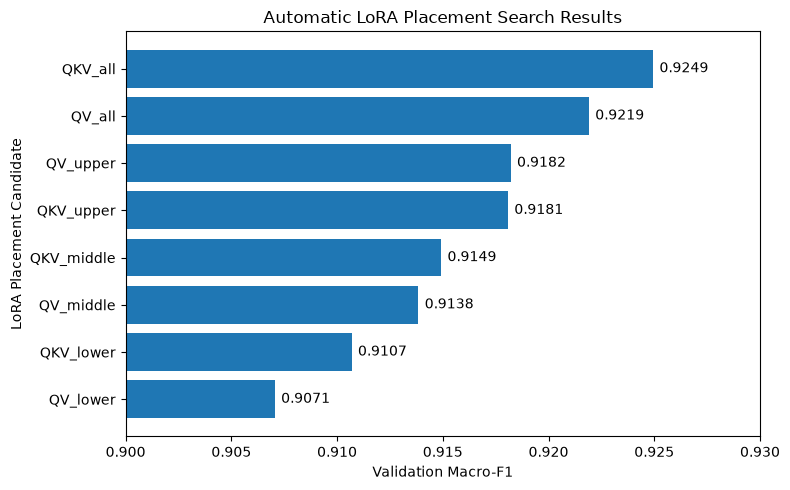

Figure saved to:
formal_results\final_comparison\placement_search_results.png


In [60]:
# Cell 27: LoRA Placement Search Results

import matplotlib.pyplot as plt
import pandas as pd
import os

# Load actual results from the automatic placement search
placement_results = pd.read_csv(
    os.path.join(
        RESULTS_DIR,
        "placement_search_results.csv"
    )
)[["candidate", "macro_f1"]]

# Sort from lowest to highest
placement_results = placement_results.sort_values(
    "macro_f1"
).reset_index(drop=True)

plt.figure(figsize=(8, 5))

bars = plt.barh(
    placement_results["candidate"],
    placement_results["macro_f1"]
)

plt.xlabel("Validation Macro-F1")
plt.ylabel("LoRA Placement Candidate")
plt.title("Automatic LoRA Placement Search Results")

plt.xlim(0.90, 0.93)

# Add exact values
for bar, value in zip(bars, placement_results["macro_f1"]):
    plt.text(
        value + 0.0003,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center"
    )

plt.tight_layout()

figure_path = os.path.join(
    RESULTS_DIR,
    "final_comparison",
    "placement_search_results.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

In [45]:
# Cell 28: Check saved training history files

import os
import glob

history_files = glob.glob(
    os.path.join(
        RESULTS_DIR,
        "final_comparison",
        "**",
        "*history*.csv"
    ),
    recursive=True
)

print("Number of history files:", len(history_files))

for f in history_files:
    print(f)

Number of history files: 20
formal_results\final_comparison\Frozen_BERT_seed123_history.csv
formal_results\final_comparison\Frozen_BERT_seed231_history.csv
formal_results\final_comparison\Frozen_BERT_seed42_history.csv
formal_results\final_comparison\Frozen_BERT_seed456_history.csv
formal_results\final_comparison\Frozen_BERT_seed789_history.csv
formal_results\final_comparison\Full_FT_seed123_history.csv
formal_results\final_comparison\Full_FT_seed231_history.csv
formal_results\final_comparison\Full_FT_seed42_history.csv
formal_results\final_comparison\Full_FT_seed456_history.csv
formal_results\final_comparison\Full_FT_seed789_history.csv
formal_results\final_comparison\Selected_LoRA_seed123_history.csv
formal_results\final_comparison\Selected_LoRA_seed231_history.csv
formal_results\final_comparison\Selected_LoRA_seed42_history.csv
formal_results\final_comparison\Selected_LoRA_seed456_history.csv
formal_results\final_comparison\Selected_LoRA_seed789_history.csv
formal_results\final_comp

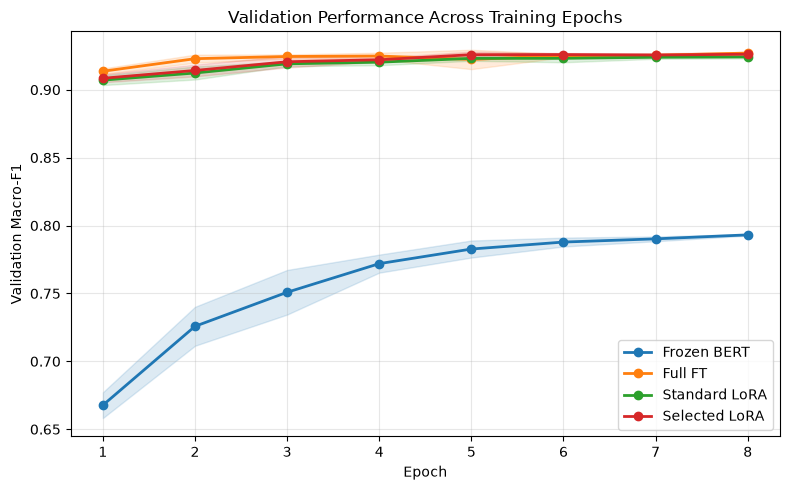

Figure saved to:
formal_results\final_comparison\validation_macro_f1_convergence.png


In [46]:
# Cell 28: Validation Macro-F1 Convergence Curves
# Mean ± standard deviation across 5 seeds

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

methods = [
    "Frozen_BERT",
    "Full_FT",
    "Standard_LoRA",
    "Selected_LoRA"
]

labels = {
    "Frozen_BERT": "Frozen BERT",
    "Full_FT": "Full FT",
    "Standard_LoRA": "Standard LoRA",
    "Selected_LoRA": "Selected LoRA"
}

history_dir = os.path.join(
    RESULTS_DIR,
    "final_comparison"
)

plt.figure(figsize=(8, 5))

for method in methods:

    files = sorted(
        glob.glob(
            os.path.join(
                history_dir,
                f"{method}_seed*_history.csv"
            )
        )
    )

    method_histories = []

    for file in files:
        df = pd.read_csv(file)

        # Keep validation rows only
        if "eval_macro_f1" in df.columns:
            temp = df[
                ["epoch", "eval_macro_f1"]
            ].dropna().copy()

            temp = temp.rename(
                columns={"eval_macro_f1": "macro_f1"}
            )

            method_histories.append(temp)

    # Combine five seeds by epoch
    combined = pd.concat(
        method_histories,
        ignore_index=True
    )

    summary = (
        combined
        .groupby("epoch")["macro_f1"]
        .agg(["mean", "std"])
        .reset_index()
    )

    # Mean curve
    line, = plt.plot(
        summary["epoch"],
        summary["mean"],
        marker="o",
        linewidth=2,
        label=labels[method]
    )

    # ± 1 standard deviation
    plt.fill_between(
        summary["epoch"],
        summary["mean"] - summary["std"].fillna(0),
        summary["mean"] + summary["std"].fillna(0),
        alpha=0.15,
        color=line.get_color()
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Macro-F1")
plt.title("Validation Performance Across Training Epochs")
plt.xticks(range(1, 9))

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = os.path.join(
    RESULTS_DIR,
    "final_comparison",
    "validation_macro_f1_convergence.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(figure_path)

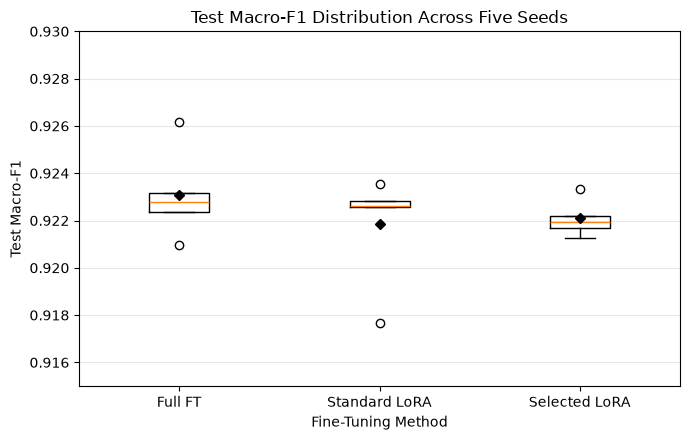

Figure saved to:
formal_results/final_comparison\test_macro_f1_boxplot.png


In [61]:
# Cell 29: Test Macro-F1 Boxplot (Three Main Methods)

import os
import pandas as pd
import matplotlib.pyplot as plt

results_dir = "formal_results/final_comparison"
results_file = os.path.join(results_dir, "final_results.csv")

df = pd.read_csv(results_file)

methods = [
    "Full_FT",
    "Standard_LoRA",
    "Selected_LoRA"
]

labels = [
    "Full FT",
    "Standard LoRA",
    "Selected LoRA"
]

data = [
    df.loc[df["method"] == method, "test_macro_f1"].values
    for method in methods
]

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.boxplot(
    data,
    tick_labels=labels,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 5
    }
)

ax.set_title("Test Macro-F1 Distribution Across Five Seeds")
ax.set_ylabel("Test Macro-F1")
ax.set_xlabel("Fine-Tuning Method")

ax.set_ylim(0.915, 0.930)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

figure_path = os.path.join(
    results_dir,
    "test_macro_f1_boxplot.png"
)

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:")
print(figure_path)